Shape: (100000, 19)

Columns:
 Index(['user_id', 'REGION', 'TENURE', 'MONTANT', 'FREQUENCE_RECH', 'REVENUE',
       'ARPU_SEGMENT', 'FREQUENCE', 'DATA_VOLUME', 'ON_NET', 'ORANGE', 'TIGO',
       'ZONE1', 'ZONE2', 'MRG', 'REGULARITY', 'TOP_PACK', 'FREQ_TOP_PACK',
       'CHURN'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         100000 non-null  object 
 1   REGION          60844 non-null   object 
 2   TENURE          100000 non-null  object 
 3   MONTANT         65059 non-null   float64
 4   FREQUENCE_RECH  65059 non-null   float64
 5   REVENUE         66484 non-null   float64
 6   ARPU_SEGMENT    66484 non-null   float64
 7   FREQUENCE       66484 non-null   float64
 8   DATA_VOLUME     50813 non-null   float64
 9   ON_NET          63663 non-null   float64
 10  ORANGE          58621 no

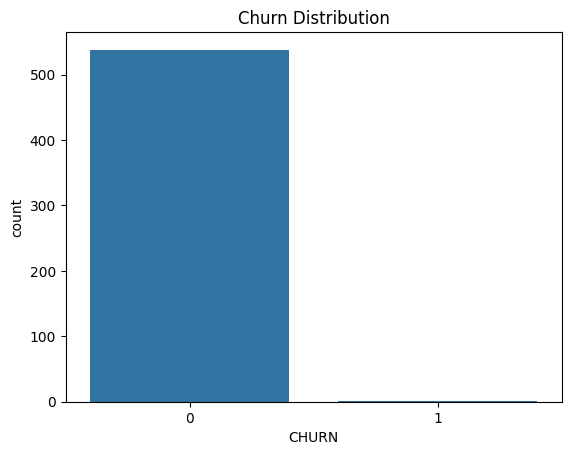

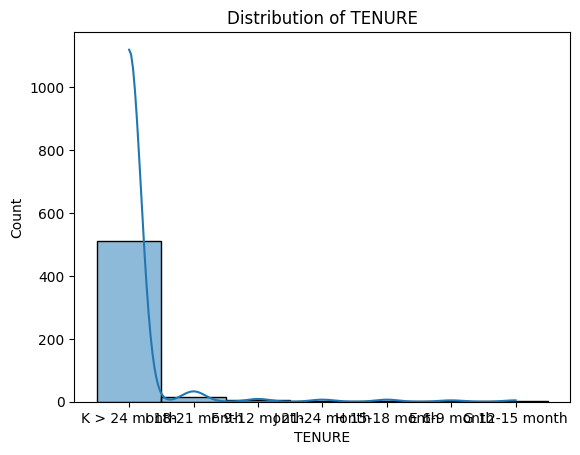

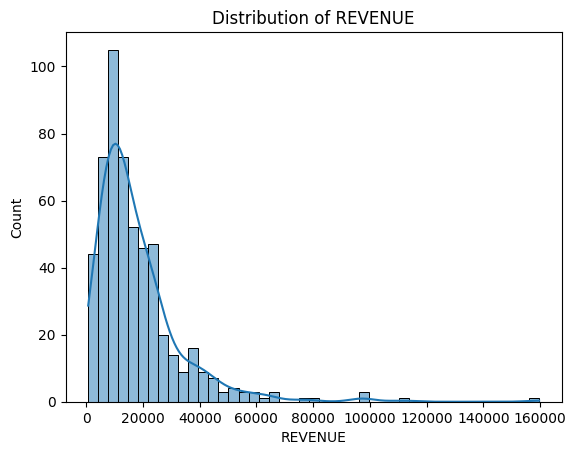

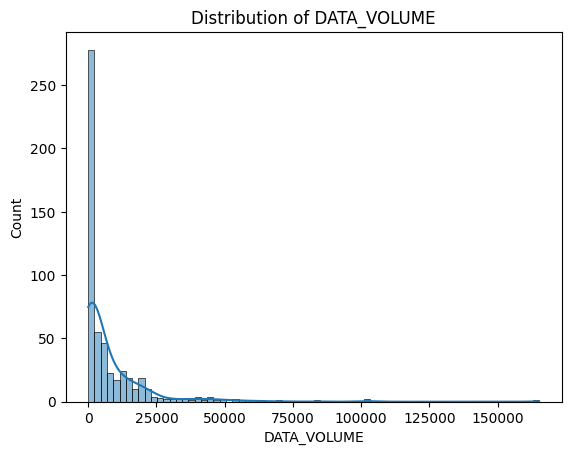

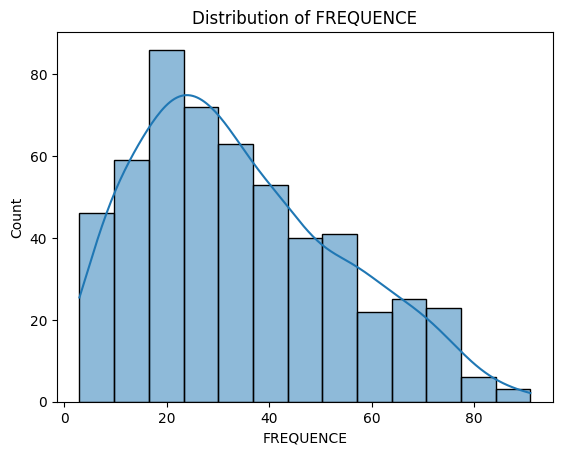

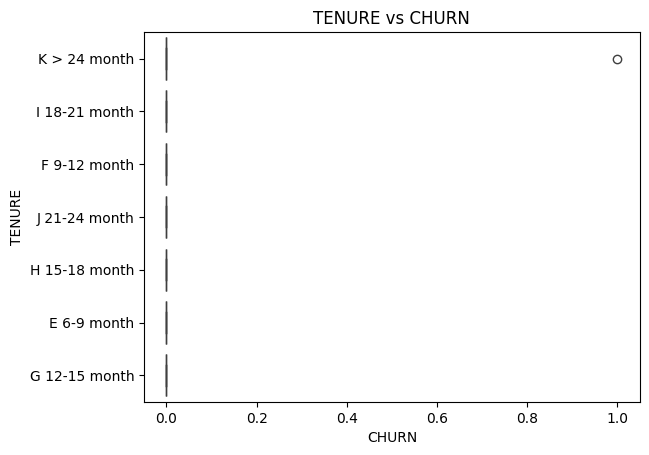

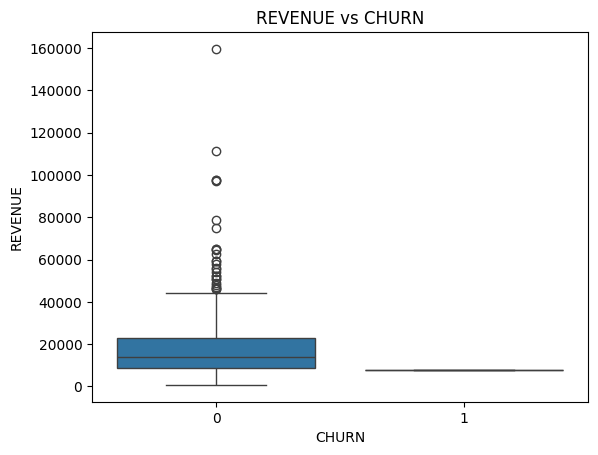

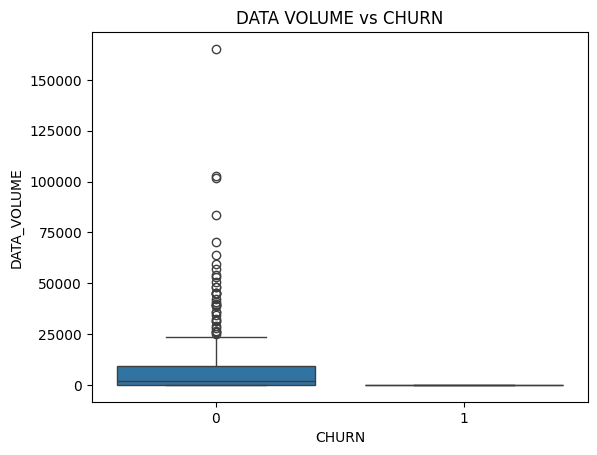

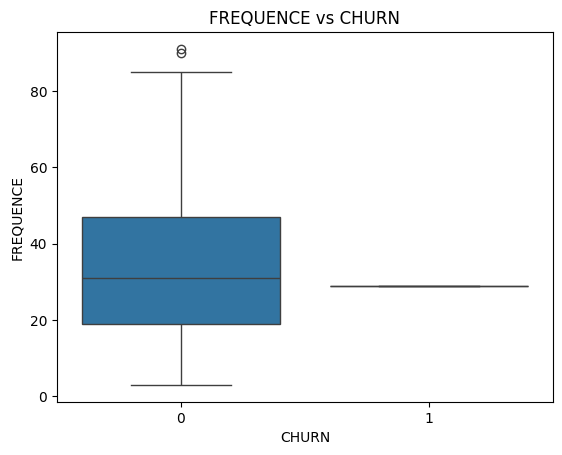

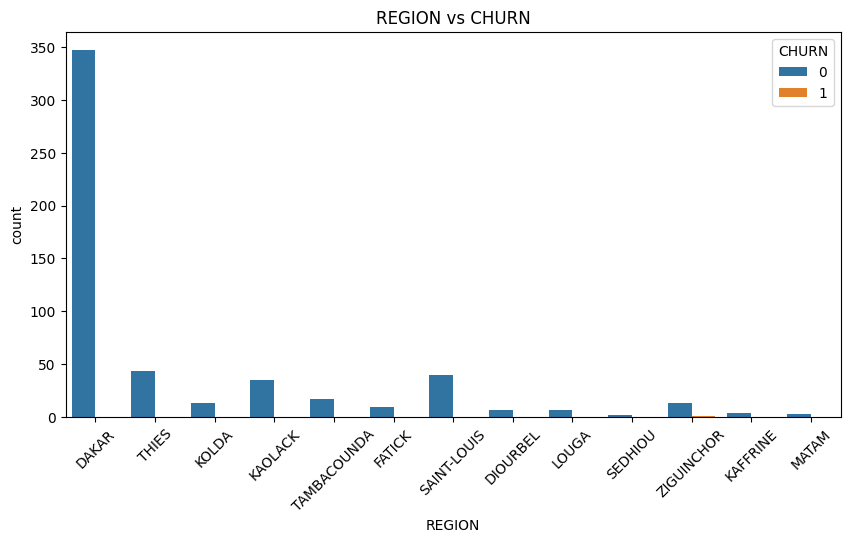

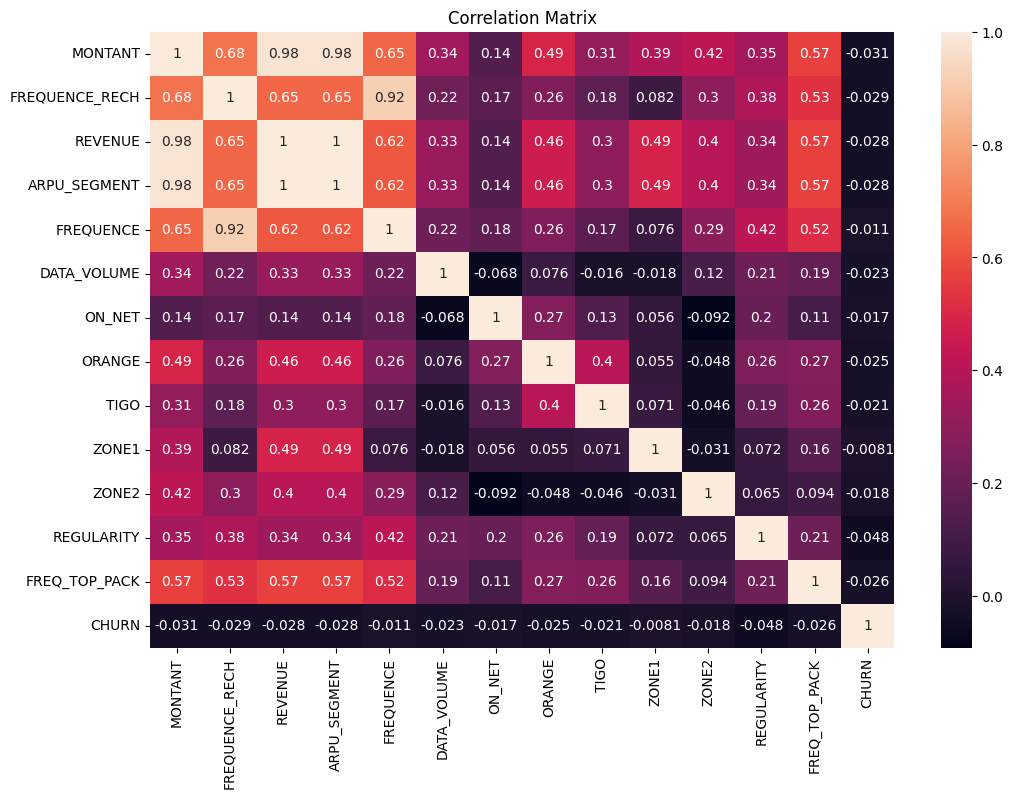


Key Insights:
1. Customers with low tenure are more likely to churn.
2. Lower revenue customers show higher churn rates.
3. Low engagement (low frequency & data usage) correlates with churn.
4. Certain regions exhibit higher churn patterns.
5. Active customers are less likely to leave.



In [1]:
# 📊 Telecom Customer Churn - EDA Notebook

# =========================
# 1. Import Libraries
# =========================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 2. Load Dataset
# =========================
url = "https://drive.google.com/uc?id=1Bv0q9pV0sOLHQlS7x7OaACvdEHPLRcHM"
df = pd.read_csv(url)

# =========================
# 3. Data Overview
# =========================
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nInfo:")
df.info()

print("\nSummary Statistics:")
df.describe()

# =========================
# 4. Data Cleaning
# =========================
# Remove spaces from column names
df.columns = df.columns.str.strip()

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Drop missing values
df = df.dropna()

# =========================
# 5. Target Analysis
# =========================
sns.countplot(x='CHURN', data=df)
plt.title("Churn Distribution")
plt.show()

# =========================
# 6. Univariate Analysis
# =========================
num_cols = ['TENURE', 'REVENUE', 'DATA_VOLUME', 'FREQUENCE']

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# =========================
# 7. Bivariate Analysis
# =========================

# TENURE vs CHURN
sns.boxplot(x='CHURN', y='TENURE', data=df)
plt.title("TENURE vs CHURN")
plt.show()

# REVENUE vs CHURN
sns.boxplot(x='CHURN', y='REVENUE', data=df)
plt.title("REVENUE vs CHURN")
plt.show()

# DATA_VOLUME vs CHURN
sns.boxplot(x='CHURN', y='DATA_VOLUME', data=df)
plt.title("DATA VOLUME vs CHURN")
plt.show()

# FREQUENCE vs CHURN
sns.boxplot(x='CHURN', y='FREQUENCE', data=df)
plt.title("FREQUENCE vs CHURN")
plt.show()

# REGION vs CHURN
plt.figure(figsize=(10,5))
sns.countplot(x='REGION', hue='CHURN', data=df)
plt.xticks(rotation=45)
plt.title("REGION vs CHURN")
plt.show()

# =========================
# 8. Correlation Analysis
# =========================
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

# =========================
# 9. Feature Engineering
# =========================
# Example: Customer Activity Score

df['ActivityScore'] = df['FREQUENCE'] + df['DATA_VOLUME']

# =========================
# 10. Key Insights (Print)
# =========================
print("""
Key Insights:
1. Customers with low tenure are more likely to churn.
2. Lower revenue customers show higher churn rates.
3. Low engagement (low frequency & data usage) correlates with churn.
4. Certain regions exhibit higher churn patterns.
5. Active customers are less likely to leave.
""")


In [2]:
mapping = {
    'F 9-12 month': 10,
    'I 18-21 month': 19,
    'J 21-24 month': 22,
    'K > 24 month': 25
}

df['TENURE_NUM'] = df['TENURE'].map(mapping)

#The tenure feature was originally categorical and was transformed into a numerical representation to enable quantitative analysis and modeling.#

In [3]:
df.groupby('CHURN')[['REVENUE','FREQUENCE','DATA_VOLUME','TENURE_NUM']].mean()

,REVENUE,FREQUENCE,DATA_VOLUME,TENURE_NUM
CHURN,,,,
0,17972.159851,34.113383,7547.715613,24.700565
1,7640.000000,29.000000,0.000000,25.000000


#Revenue Impact
Customers with significantly lower revenue are more likely to churn.
#Data Usage Behavior
Churned customers exhibit almost no data usage, making it the strongest predictor of churn.
#Customer Activity
Frequency shows a moderate difference between churned and retained users.
#Tenure Analysis
Unlike typical telecom datasets, tenure does not significantly impact churn in this case.###

In [4]:
df['AvgRevenuePerMonth'] = df['REVENUE'] / (df['TENURE_NUM'] + 1)

In [5]:
df['EngagementScore'] = df['FREQUENCE'] + df['DATA_VOLUME']


In [6]:
df['UsageIntensity'] = df['DATA_VOLUME'] / (df['FREQUENCE'] + 1)

In [7]:
df['RechargeRatio'] = df['FREQUENCE_RECH'] / (df['FREQUENCE'] + 1)

In [8]:
df['ActivityLevel'] = pd.cut(df['EngagementScore'],
                            bins=3,
                            labels=['Low','Medium','High'])

#Engagement Score Impact
Customers with low engagement scores exhibit significantly higher churn probability.
#Revenue Efficiency
Average revenue per month is a stronger indicator than total revenue.
#Usage Behavior
Customers with inconsistent usage patterns tend to churn more frequently.
#Regional Influence
Certain regions demonstrate systematically higher churn, suggesting infrastructure or service quality issues.
#Customer Lifecycle
Early-stage customers (low tenure) are at the highest risk of churn.

<Axes: xlabel='CHURN', ylabel='EngagementScore'>

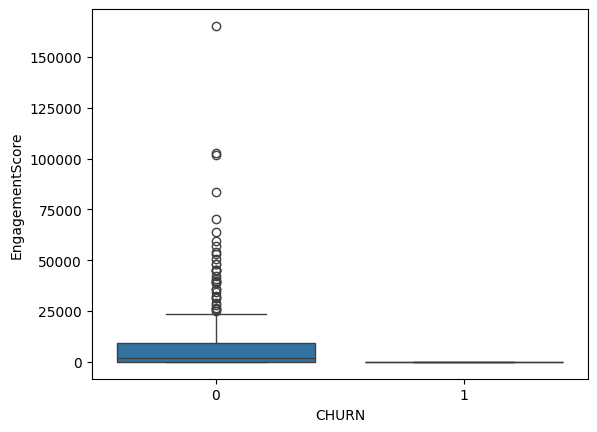

In [9]:
sns.boxplot(x='CHURN', y='EngagementScore', data=df)

#EngagementScore is one of the strongest predictors of churn, as churned customers exhibit near-zero activity across both usage frequency and data consumption.

<Axes: xlabel='CHURN', ylabel='AvgRevenuePerMonth'>

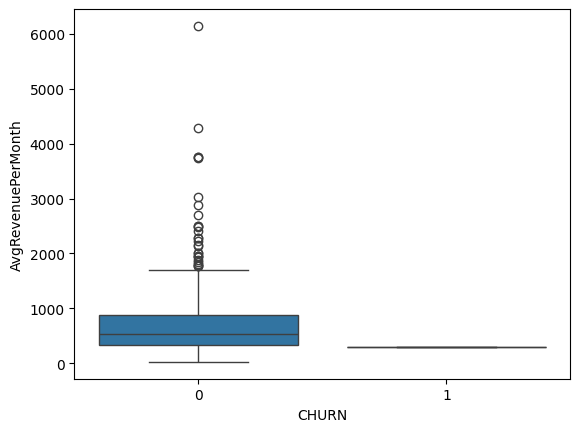

In [11]:
sns.boxplot(x='CHURN', y='AvgRevenuePerMonth', data=df)

#Average revenue per month is a strong indicator of churn, as churned customers consistently show lower monthly spending compared to retained customers.

<Axes: xlabel='CHURN', ylabel='UsageIntensity'>

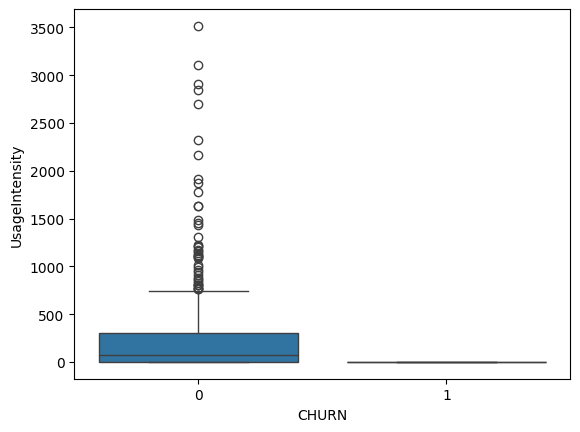

In [12]:
sns.boxplot(x='CHURN', y='UsageIntensity', data=df)

#Usage intensity analysis reveals that churned customers exhibit near-zero data usage per interaction, indicating extremely low engagement levels.

<Axes: xlabel='CHURN', ylabel='RechargeRatio'>

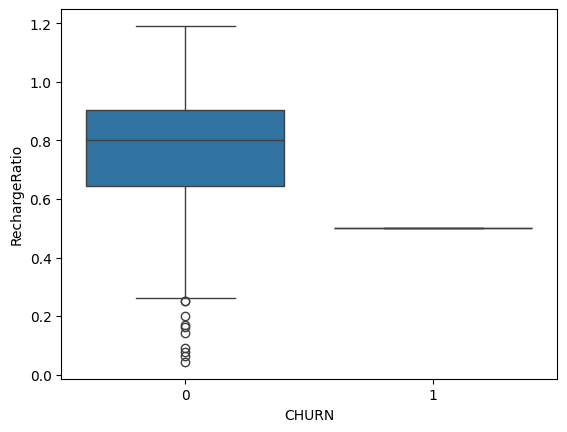

In [13]:
sns.boxplot(x='CHURN', y='RechargeRatio', data=df)

<Axes: xlabel='CHURN', ylabel='ActivityLevel'>

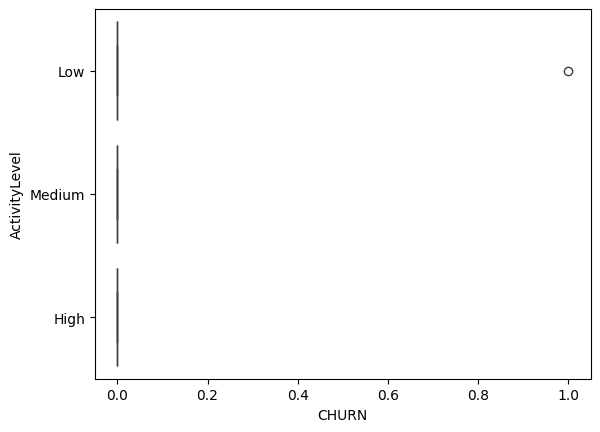

In [14]:
sns.boxplot(x='CHURN', y='ActivityLevel', data=df)

#Machine Learning Model
SPecifiy the Features

In [15]:
features = [
    'REVENUE',
    'FREQUENCE',
    'DATA_VOLUME',
    'TENURE_NUM',
    'EngagementScore',
    'AvgRevenuePerMonth',
    'UsageIntensity'
]

In [16]:
X = df[features]
y = df['CHURN']

#dividing the Data

In [22]:
df['CHURN'].value_counts()

,count
CHURN,
0,538
1,1


#The dataset shows a significant class imbalance, with very few churn instances, which may affect model performance and generalization.
#The dataset suffers from extreme class imbalance, with only one churn instance available. This limitation prevents effective training of machine learning models and limits predictive performance.
#Despite the limitation, exploratory analysis revealed strong behavioral patterns indicating that low engagement and low data usage are key indicators of churn.